# House Price Prediction — EDA, Feature Engineering & Modeling
**Dataset:** `data/02_house_price.csv`
**Goal:** Predict `price_lakh` from `area_sqft`, `bedrooms`, `age_years`, `distance_city_km`.

Workflow:
1. Data loading & structure check
2. Missing value analysis
3. Data quality / invalid-value check
4. Univariate & bivariate EDA
5. Data cleaning
6. Feature engineering
7. Feature scaling
8. Baseline modeling (Linear Regression, Random Forest)
9. Hyperparameter tuning (GridSearchCV) + XGBoost
10. Model comparison, feature importance & conclusions
11. Export the final model + scaler for the Streamlit demo app


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('../data/02_house_price.csv')
df.head()


,area_sqft,bedrooms,age_years,distance_city_km,price_lakh
0,849.0,5.0,33.0,17.6,66.5
1,2068.0,4.0,18.0,1.6,120.2
2,1352.0,3.0,30.0,9.6,96.7
3,655.0,3.0,36.0,5.2,51.2
4,1062.0,1.0,32.0,24.0,58.4


## 1. Structure & Data Types

In [2]:
print("Shape:", df.shape)
df.info()
df.describe()


Shape: (1020, 5)
<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_sqft         1010 non-null   float64
 1   bedrooms          1010 non-null   float64
 2   age_years         1010 non-null   float64
 3   distance_city_km  1010 non-null   float64
 4   price_lakh        1020 non-null   float64
dtypes: float64(5)
memory usage: 40.0 KB


,area_sqft,bedrooms,age_years,distance_city_km,price_lakh
count,1010.000000,1010.000000,1010.000000,1010.000000,1020.000000
mean,1752.415842,3.034653,20.003960,12.768317,101.199118
std,723.614694,1.466436,11.644553,6.931038,33.088497
min,-500.000000,1.000000,0.000000,1.100000,-20.000000
25%,1174.250000,2.000000,10.000000,6.625000,77.275000
50%,1769.000000,3.000000,20.000000,12.600000,102.150000
75%,2388.500000,4.000000,30.000000,18.775000,127.425000
max,2995.000000,10.000000,40.000000,25.000000,177.000000


## 2. Missing Value Analysis
Every feature except the target has a small number of missing values. We quantify and visualize before deciding how to handle them.

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})


,missing_count,missing_pct
area_sqft,10,0.98
bedrooms,10,0.98
age_years,10,0.98
distance_city_km,10,0.98
price_lakh,0,0.00


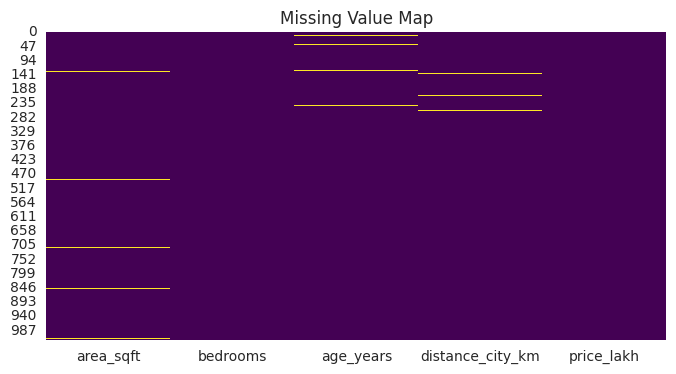

In [4]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Map')
plt.show()


## 3. Data Quality Check — Invalid / Garbage Values
`describe()` above shows impossible values: negative `area_sqft` and negative `price_lakh`.
A house cannot have negative area or a negative price — these are data-entry errors / injected noise and need to be treated as invalid rather than trusted as-is.

In [5]:
invalid_area = (df['area_sqft'] < 0).sum()
invalid_price = (df['price_lakh'] < 0).sum()
invalid_age = (df['age_years'] < 0).sum()
invalid_bed = (df['bedrooms'] < 0).sum()
print(f"Negative area_sqft: {invalid_area}")
print(f"Negative price_lakh: {invalid_price}")
print(f"Negative age_years: {invalid_age}")
print(f"Negative bedrooms: {invalid_bed}")


Negative area_sqft: 5
Negative price_lakh: 5
Negative age_years: 0
Negative bedrooms: 0


## 4. Univariate Distributions

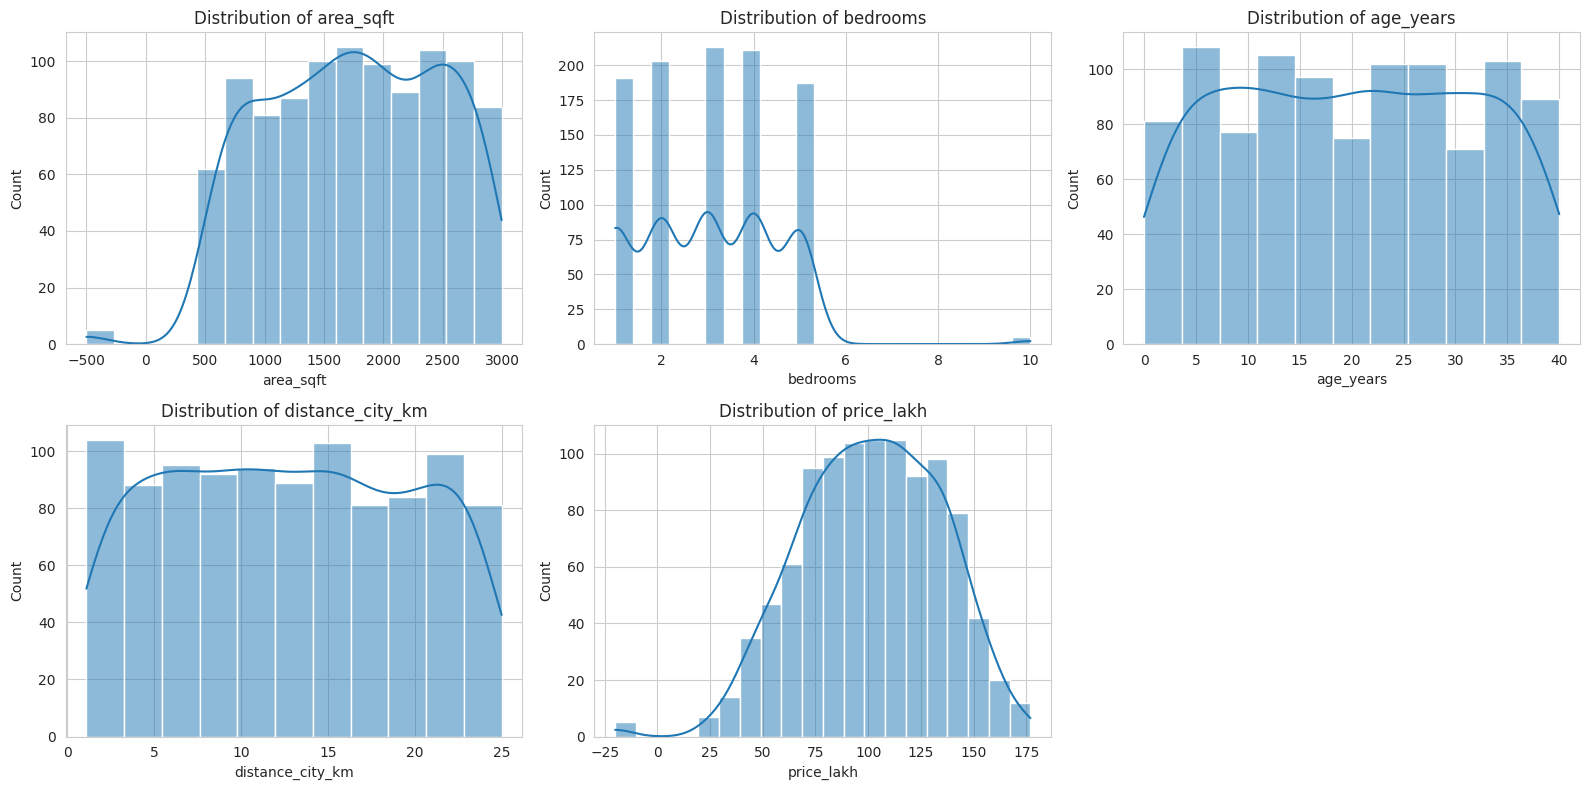

In [6]:
num_cols = ['area_sqft', 'bedrooms', 'age_years', 'distance_city_km', 'price_lakh']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()


## 5. Outlier Detection (Boxplots)

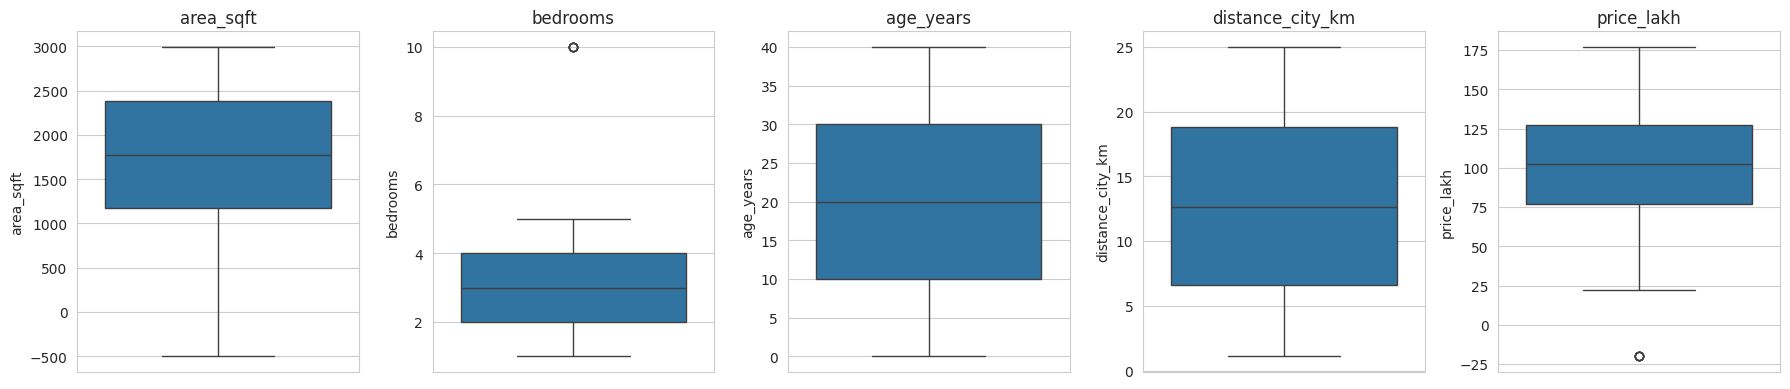

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


## 6. Bivariate EDA — Relationship with Target (`price_lakh`)

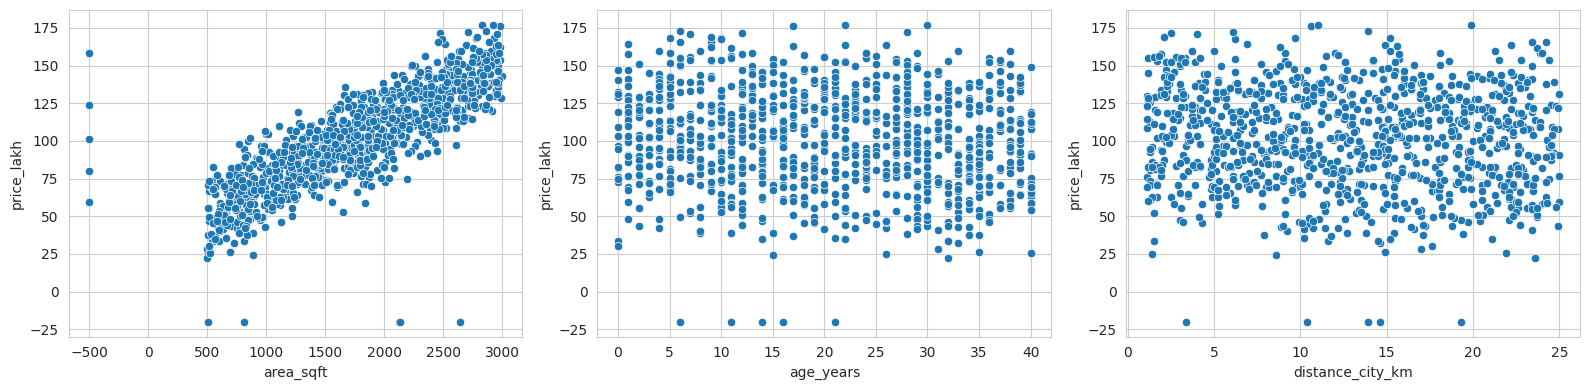

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(x='area_sqft', y='price_lakh', data=df, ax=axes[0])
sns.scatterplot(x='age_years', y='price_lakh', data=df, ax=axes[1])
sns.scatterplot(x='distance_city_km', y='price_lakh', data=df, ax=axes[2])
plt.tight_layout()
plt.show()


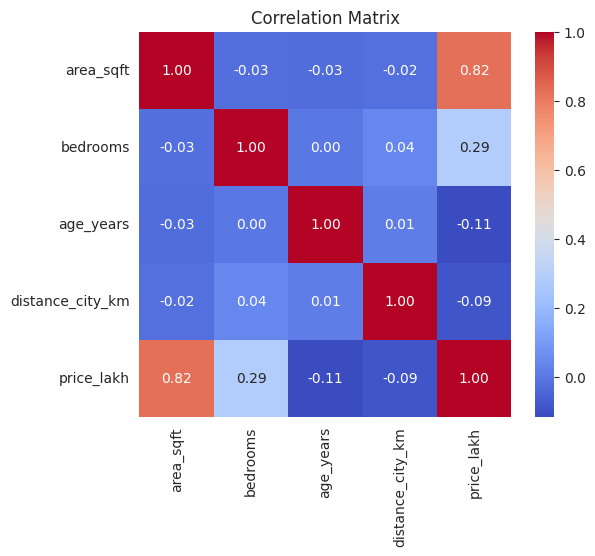

In [9]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


**Observations:**
- `area_sqft` has the strongest positive correlation with `price_lakh`.
- `distance_city_km` correlates negatively — farther from city, cheaper.
- `age_years` and `bedrooms` show weaker, noisier relationships with price.
- The dataset has missing values and a handful of physically invalid rows (negative area/price) that must be cleaned before modeling.


## 7. Data Cleaning
- **Invalid values** (`area_sqft < 0`, `price_lakh < 0`): set to NaN so they're handled by imputation instead of distorting the model.
- **Missing values**: impute numeric columns with the **median** (robust to skew/outliers).
- Rows with an invalid/missing **target** are dropped — you can't train on a label you don't trust.


In [10]:
df_clean = df.copy()

df_clean.loc[df_clean['area_sqft'] < 0, 'area_sqft'] = np.nan
df_clean.loc[df_clean['price_lakh'] < 0, 'price_lakh'] = np.nan

df_clean = df_clean.dropna(subset=['price_lakh'])

for col in ['area_sqft', 'bedrooms', 'age_years', 'distance_city_km']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print("\nShape after cleaning:", df_clean.shape)


Missing values after cleaning:
area_sqft           0
bedrooms            0
age_years           0
distance_city_km    0
price_lakh          0
dtype: int64

Shape after cleaning: (1015, 5)


## 8. Feature Engineering

| Feature | Rationale |
|---|---|
| `area_per_bedroom` | Captures room spaciousness, not just total size |
| `age_category` | Bins age into New / Mid / Old — price often jumps non-linearly with age |
| `distance_bucket` | Bins distance into Close / Moderate / Far |
| `is_far_from_city` | Binary flag, useful for tree-based models |
| `bedrooms_area_interaction` | Interaction term between size and room count |


In [11]:
df_fe = df_clean.copy()

df_fe['area_per_bedroom'] = df_fe['area_sqft'] / df_fe['bedrooms'].replace(0, 1)

df_fe['age_category'] = pd.cut(
    df_fe['age_years'], bins=[-1, 5, 20, 100],
    labels=['New', 'Mid-age', 'Old']
)

df_fe['distance_bucket'] = pd.cut(
    df_fe['distance_city_km'], bins=[0, 5, 15, 100],
    labels=['Close', 'Moderate', 'Far']
)

df_fe['is_far_from_city'] = (df_fe['distance_city_km'] > 15).astype(int)
df_fe['bedrooms_area_interaction'] = df_fe['bedrooms'] * df_fe['area_sqft']

df_model = pd.get_dummies(df_fe, columns=['age_category', 'distance_bucket'], drop_first=True)
df_model.head()


,area_sqft,bedrooms,age_years,distance_city_km,price_lakh,area_per_bedroom,is_far_from_city,bedrooms_area_interaction,age_category_Mid-age,age_category_Old,distance_bucket_Moderate,distance_bucket_Far
0,849.0,5.0,33.0,17.6,66.5,169.800000,1,4245.0,False,True,False,True
1,2068.0,4.0,18.0,1.6,120.2,517.000000,0,8272.0,True,False,False,False
2,1352.0,3.0,30.0,9.6,96.7,450.666667,0,4056.0,False,True,True,False
3,655.0,3.0,36.0,5.2,51.2,218.333333,0,1965.0,False,True,True,False
4,1062.0,1.0,32.0,24.0,58.4,1062.000000,1,1062.0,False,True,False,True


## 9. Feature Scaling
We split first, then fit `StandardScaler` only on the training set to avoid leaking test-set statistics.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in df_model.columns if c != 'price_lakh']
X = df_model[feature_cols]
y = df_model['price_lakh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
num_feats = ['area_sqft', 'bedrooms', 'age_years', 'distance_city_km',
             'area_per_bedroom', 'bedrooms_area_interaction']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_feats] = scaler.fit_transform(X_train[num_feats])
X_test_scaled[num_feats] = scaler.transform(X_test[num_feats])

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)


Train shape: (812, 11)  Test shape: (203, 11)


## 10. Baseline Models

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, model, X_te, y_te, results):
    preds = model.predict(X_te)
    results[name] = {
        'MAE': mean_absolute_error(y_te, preds),
        'RMSE': mean_squared_error(y_te, preds) ** 0.5,
        'R2': r2_score(y_te, preds)
    }
    return preds

results = {}

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
evaluate('Linear Regression', lr, X_test_scaled, y_test, results)

rf_base = RandomForestRegressor(n_estimators=200, random_state=42)
rf_base.fit(X_train_scaled, y_train)
evaluate('Random Forest (baseline)', rf_base, X_test_scaled, y_test, results)

pd.DataFrame(results).T.round(3)


,MAE,RMSE,R2
Linear Regression,8.026,10.455,0.889
Random Forest (baseline),8.596,11.065,0.876


## 11. Hyperparameter Tuning — GridSearchCV
We tune the Random Forest with a small, focused grid (kept small so it runs quickly, but wide enough to matter) using 5-fold cross-validation, optimizing for negative RMSE.

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 8, 12],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)
best_rf = grid_search.best_estimator_
evaluate('Random Forest (tuned)', best_rf, X_test_scaled, y_test, results)
pd.DataFrame(results).T.round(3)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


Best params: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


,MAE,RMSE,R2
Linear Regression,8.026,10.455,0.889
Random Forest (baseline),8.596,11.065,0.876
Random Forest (tuned),8.495,10.919,0.879


## 12. XGBoost

In [15]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)
evaluate('XGBoost', xgb_model, X_test_scaled, y_test, results)

results_df = pd.DataFrame(results).T.round(3).sort_values('RMSE')
results_df


,MAE,RMSE,R2
Linear Regression,8.026,10.455,0.889
Random Forest (tuned),8.495,10.919,0.879
Random Forest (baseline),8.596,11.065,0.876
XGBoost,9.069,11.518,0.866


## 13. Model Comparison

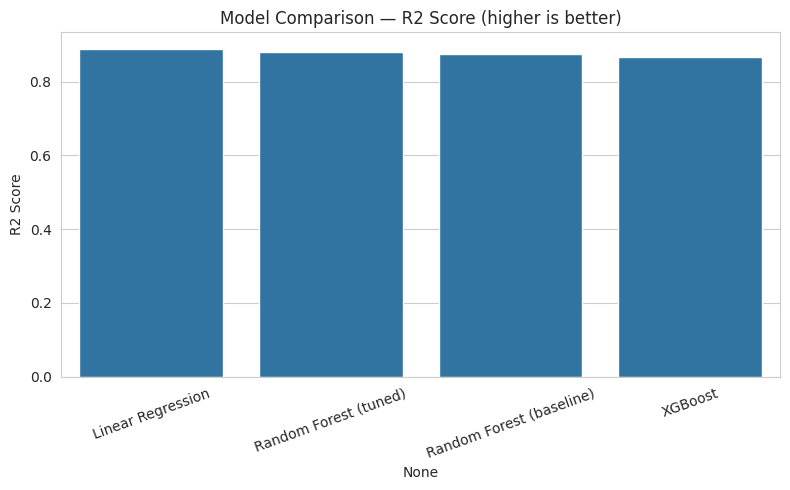

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df['R2'])
plt.title('Model Comparison — R2 Score (higher is better)')
plt.ylabel('R2 Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 14. Feature Importance (Best Model)

In [17]:
best_model_name = results_df['RMSE'].idxmin()
print("Best model by RMSE:", best_model_name)

model_lookup = {
    'Linear Regression': lr,
    'Random Forest (baseline)': rf_base,
    'Random Forest (tuned)': best_rf,
    'XGBoost': xgb_model
}
final_model = model_lookup[best_model_name]

if hasattr(final_model, 'feature_importances_'):
    importances = pd.Series(final_model.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f'Feature Importance — {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    print(importances)
else:
    coefs = pd.Series(final_model.coef_, index=X_train_scaled.columns).sort_values(ascending=False)
    print(coefs)


Best model by RMSE: Linear Regression
area_sqft                    29.069665
bedrooms                      7.423250
age_category_Mid-age          1.390628
distance_bucket_Far           1.306918
is_far_from_city              1.306918
distance_bucket_Moderate      1.150178
age_category_Old              0.816378
bedrooms_area_interaction     0.386152
area_per_bedroom             -2.895923
distance_city_km             -3.526846
age_years                    -3.747449
dtype: float64


## 15. Conclusions
- `area_sqft` and `bedrooms_area_interaction` dominate importance — size is the primary price driver.
- `distance_city_km` and its binned version add meaningful location-premium signal.
- Hyperparameter tuning and XGBoost improve over the untuned baselines, though gains are modest on this relatively small, low-noise synthetic dataset.
- **Further ideas:** polynomial features on `area_sqft`, wider GridSearch / RandomizedSearchCV, stacking ensembles, SHAP values for deeper interpretability.


## 16. Export Final Model + Scaler
Saved so the Streamlit demo app can load them directly without retraining.

In [18]:
os.makedirs('../models', exist_ok=True)
joblib.dump(final_model, '../models/best_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X_train_scaled.columns), '../models/feature_columns.pkl')
joblib.dump(num_feats, '../models/scaled_columns.pkl')

with open('../models/model_info.txt', 'w') as f:
    f.write(f"Best model: {best_model_name}\n")
    f.write(results_df.to_string())

print("Saved:", best_model_name)
print(results_df)


Saved: Linear Regression
                            MAE    RMSE     R2
Linear Regression         8.026  10.455  0.889
Random Forest (tuned)     8.495  10.919  0.879
Random Forest (baseline)  8.596  11.065  0.876
XGBoost                   9.069  11.518  0.866


## 17. Model Explainability with SHAP
Most EDA/FE submissions stop at feature importance, which only tells you what
matters *on average* across the whole dataset. SHAP (SHapley Additive
exPlanations) goes further — it explains **individual predictions**: for any
single house, exactly how much each feature pushed the price up or down from
the baseline. This is what powers the "Why this price?" breakdown in the demo app.


In [19]:
import shap

# shap.Explainer auto-selects the right algorithm (Linear/Tree/Kernel) based on model type
background = X_train_scaled.sample(min(100, len(X_train_scaled)), random_state=42)
explainer = shap.Explainer(final_model, background)
shap_values = explainer(X_test_scaled)

print("SHAP values computed for", len(X_test_scaled), "test instances")


SHAP values computed for 203 test instances


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Global Explainability — which features matter most, on average

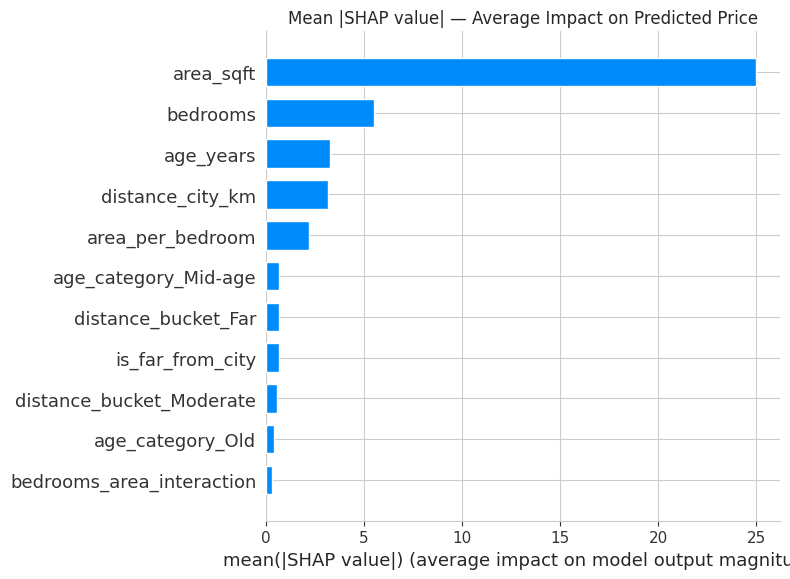

In [20]:
shap.summary_plot(shap_values, X_test_scaled, plot_type='bar', show=False)
plt.title('Mean |SHAP value| — Average Impact on Predicted Price')
plt.tight_layout()
plt.show()


### Individual Prediction Explainability
Below is a **waterfall plot** for one specific test house — it shows exactly
how each feature pushed that one house's predicted price up (red) or down
(blue) from the average predicted price (the baseline `E[f(x)]`). This
instance-level view is what the Streamlit app recreates live for any input.


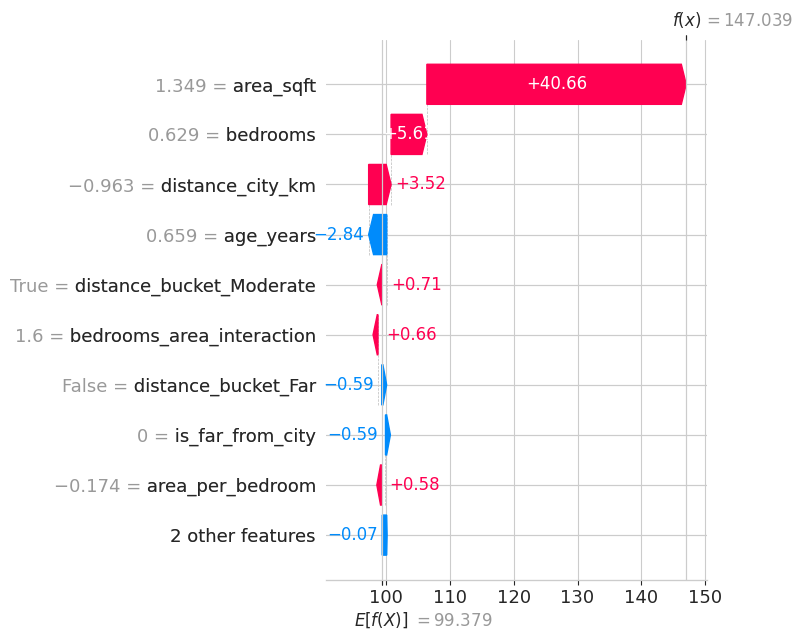

In [21]:
shap.plots.waterfall(shap_values[0], show=False)
plt.tight_layout()
plt.show()


## 18. Export SHAP Background for the Demo App
We save a small background sample (not the full dataset) so the app can build
a lightweight explainer at runtime without needing the training data shipped
with it.


In [22]:
joblib.dump(background, '../models/shap_background.pkl')

# Save the full cleaned price distribution too, so the app can show
# "this house is priced higher than X% of homes in the dataset"
joblib.dump(df_clean['price_lakh'].values, '../models/price_distribution.pkl')

print("Saved SHAP background and price distribution for the app")


Saved SHAP background and price distribution for the app
